In [1]:
# Evaluate roi sizes/depths etc.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from paiskintonetools import setup_matplotlib  #  type:ignore

import seaborn as sns
from scipy.stats import linregress

setup_matplotlib()

In [3]:
columns_of_interest = [
    "SkinID",
    "RunNumber",
    "Region",
    "Pigment",
    "ROI Name",
    "ROI Number",
    "Side",
    "ITA",
    "Location",
    "VitiligoPigment",
    "Parallel",
    "OtherDetail",
    "VitiligoLeftRight",
    "ROI x",
    "ROI y",
    "ROI area",
    "spectrum_positive_mean",
    "thb_mean",
    "so2_mean",
    "Age range",
    "Gender",
    "Fitzpatrick Type",
    "BMI",
]

df = pd.read_parquet("tables/pa_values_extracted_all_meta.parquet")[columns_of_interest]
df = df[df["Fitzpatrick Type"] != "Vitiligo"]
df = df[df["Parallel"] != "parallel"]

In [4]:
df.head()

,SkinID,RunNumber,Region,Pigment,ROI Name,ROI Number,Side,ITA,Location,VitiligoPigment,...,ROI x,ROI y,ROI area,spectrum_positive_mean,thb_mean,so2_mean,Age range,Gender,Fitzpatrick Type,BMI
0,SKIN01,1,Bicep,,fat,0,,70.37,bicep,,...,-1.925957e-03,0.002114,0.000604,"[0.001716353577853154, 0.0014200486014481436, ...",-9.087599e-07,0.574090,20-29,Male,2,25.5
1,SKIN01,1,Bicep,,muscle,0,,70.37,bicep,,...,4.520362e-04,-0.008895,0.002635,"[0.001066501621402313, 0.0008687284441931311, ...",-4.937560e-07,0.637296,20-29,Male,2,25.5
2,SKIN01,1,Bicep,,muscle ellipse,0,,70.37,bicep,,...,1.850344e-20,-0.000641,0.000067,"[0.0019916069826481264, 0.0017164469554923605,...",5.651419e-07,0.657129,20-29,Male,2,25.5
3,SKIN01,1,Bicep,,skin,0,,70.37,bicep,,...,-2.713660e-04,0.004973,0.000521,"[0.005841850850162988, 0.00517023815385639, 0....",3.175336e-06,0.376695,20-29,Male,2,25.5
4,SKIN01,1,Bicep,,fat,0,,70.37,bicep,,...,-3.077840e-03,0.001444,0.000655,"[0.001774744513027185, 0.0015237122321907644, ...",-6.038437e-07,0.601975,20-29,Male,2,25.5


In [5]:
agg_function = {
    k: (
        "first"
        if isinstance(df[k].iloc[0], str)
        else (
            (lambda x: np.median(np.stack(x), axis=0))
            if isinstance(df[k].iloc[0], np.ndarray)
            else "median"
        )
    )
    for k in columns_of_interest
}

In [6]:
mean_values = (
    df.groupby(["SkinID", "Region", "ROI Name", "RunNumber"])
    .agg(agg_function)
    .reset_index(drop=True)
    .groupby(["SkinID", "Region", "ROI Name"])
    .agg(agg_function)
)

mean_values["ROI area"] *= 1e6
mean_values["ROI y"] = (0.0052 - mean_values["ROI y"]) * 1e3

In [7]:
mean_values["PA700"] = mean_values["spectrum_positive_mean"].apply(lambda x: x[0])

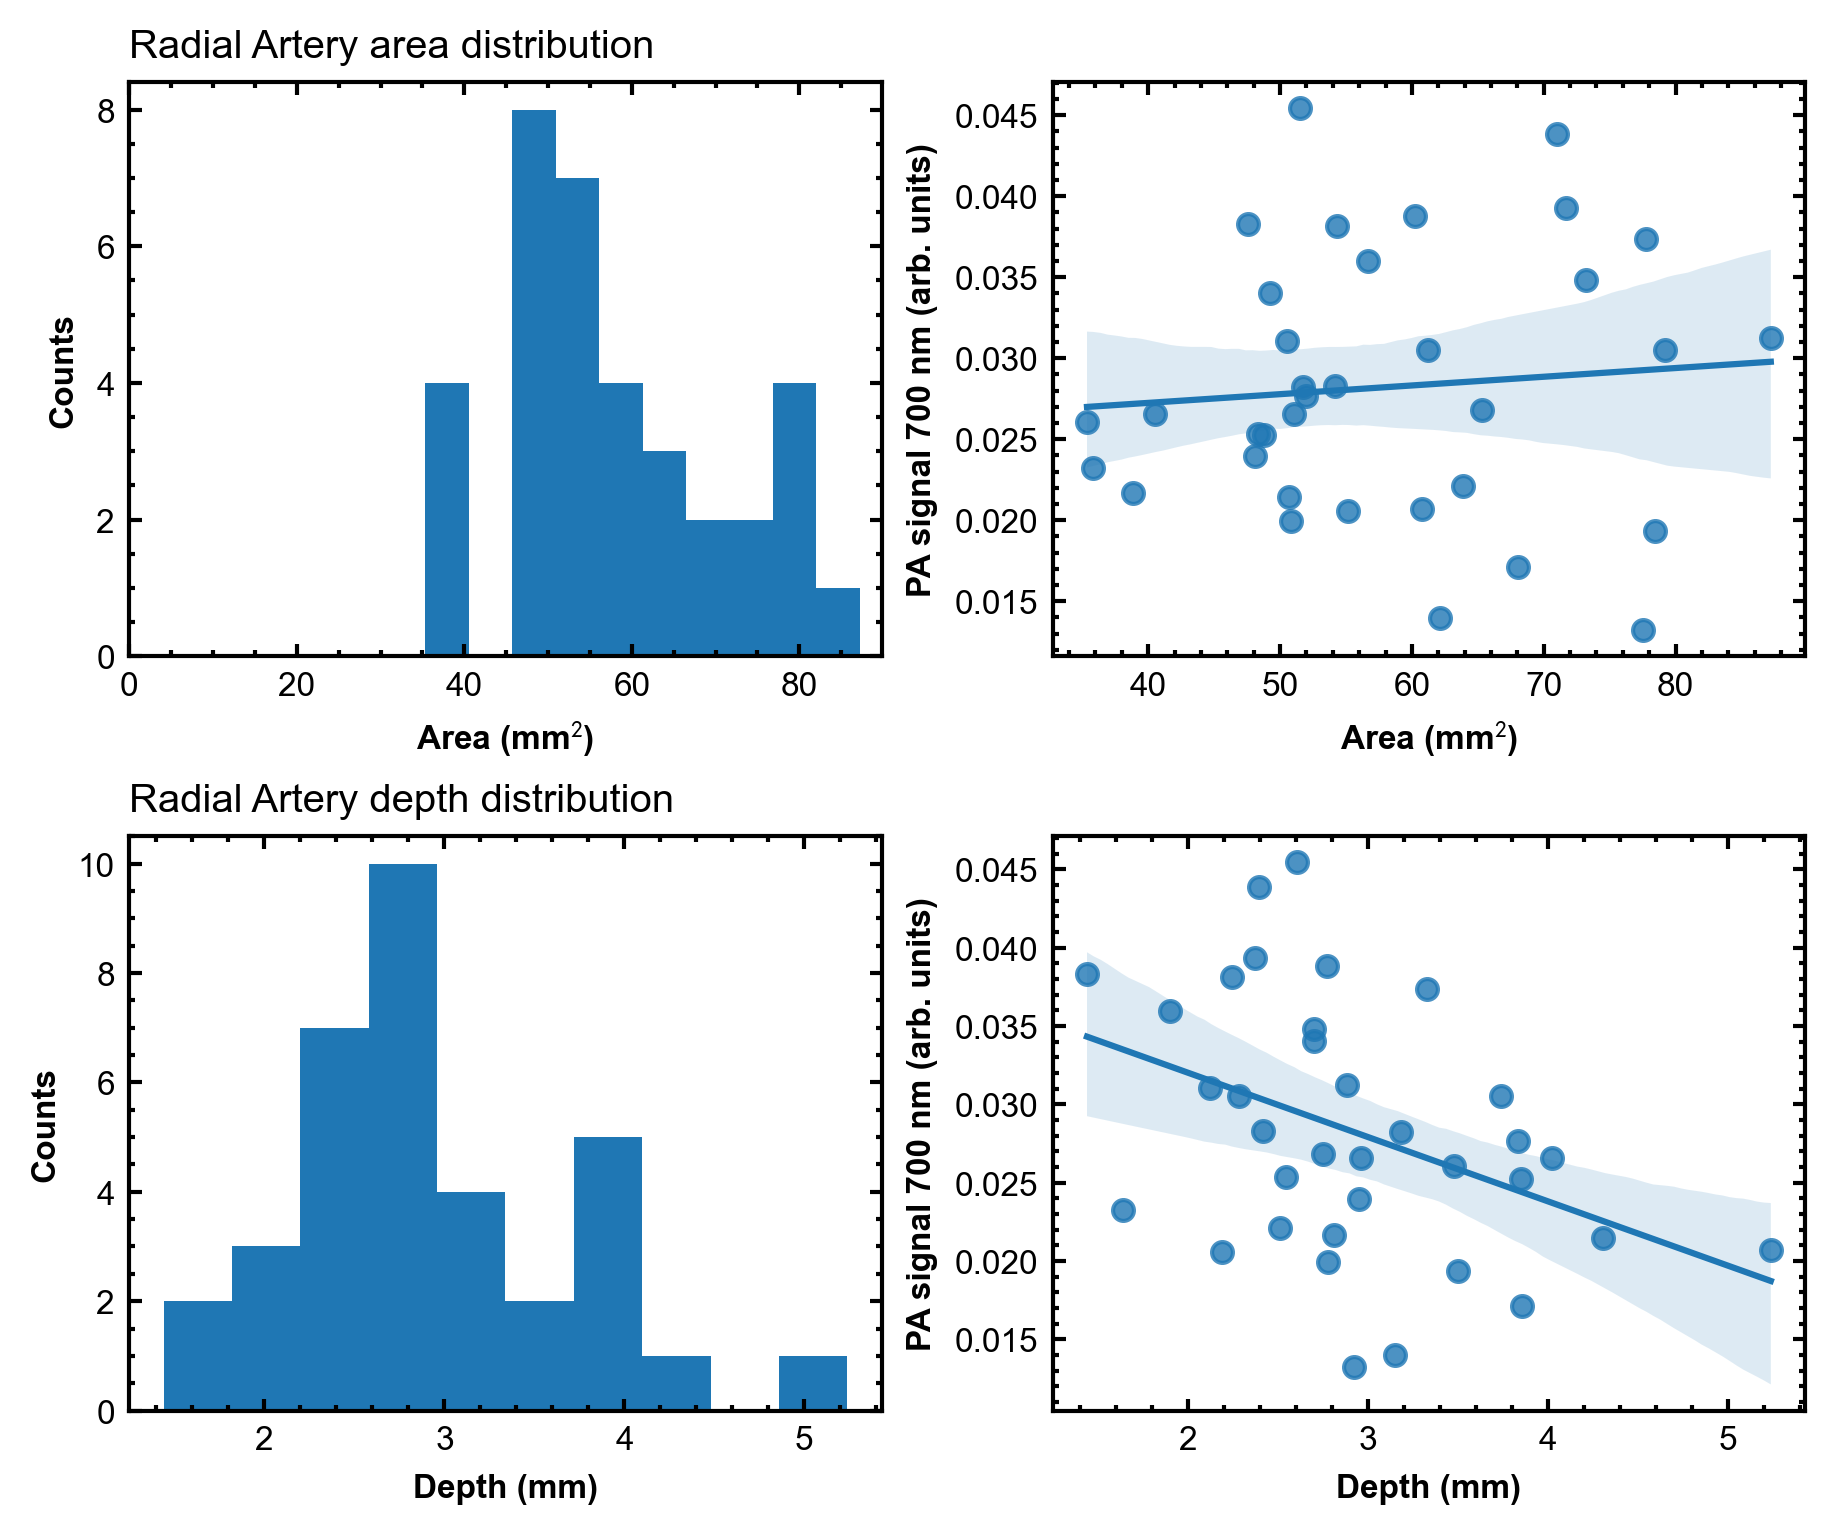

Area: Mean = 57.97 mm^2, Standard deviation = 13.08 mm^2, Percentage variation = 22.57 %
Diameter = 8.54 mm, Standard deviation = 0.97 mm, Percentage variation = 11.32 %
Depth: Mean = 2.93 mm, Standard deviation = 0.79 mm, Percentage variation = 26.87 %


In [8]:
region = "Radial Artery"
roi_name = "artery" if "artery" in region.lower() else "muscle"

fig, ((ax1, ax2), (ax4, ax3)) = plt.subplots(2, 2, figsize=(6, 5))

region_values = mean_values.query(
    f"`ROI Name` == '{roi_name}' and Region == '{region}'"
)

ax1.hist(
    region_values["ROI area"],
    bins=10,
)
ax1.set_xlabel("Area (mm$^2$)")
ax1.set_ylabel("Counts")
ax1.set_title(f"{region} area distribution", fontweight="normal", loc="left")
ax1.set_xlim([0, None])

# Plot the area against signal.
sns.regplot(data=region_values, x="ROI area", y="PA700", ax=ax2)

# ax2.scatter(region_values["ROI area"], region_values["PA700"])
ax2.set_xlabel("Area (mm$^2$)")
ax2.set_ylabel("PA signal 700 nm (arb. units)")

# Plot the area against signal.
sns.regplot(data=region_values, x="ROI y", y="PA700", ax=ax3)

# ax2.scatter(region_values["ROI area"], region_values["PA700"])
ax3.set_xlabel("Depth (mm)")
ax3.set_ylabel("PA signal 700 nm (arb. units)")

ax4.hist(
    region_values["ROI y"],
    bins=10,
)
ax4.set_xlabel("Depth (mm)")
ax4.set_ylabel("Counts")
ax4.set_title(f"{region} depth distribution", fontweight="normal", loc="left")
plt.show()
mean = region_values["ROI area"].mean()
std = region_values["ROI area"].std()
print(
    "Area: Mean = {:.2f} mm^2, Standard deviation = {:.2f} mm^2, Percentage variation = {:.2f} %".format(
        mean, std, std / mean * 100
    )
)

diameter = np.sqrt(4 * region_values["ROI area"] / np.pi)
mean = diameter.mean()
std = diameter.std()
print(
    "Diameter = {:.2f} mm, Standard deviation = {:.2f} mm, Percentage variation = {:.2f} %".format(
        mean, std, std / mean * 100
    )
)

mean = region_values["ROI y"].mean()
std = region_values["ROI y"].std()
print(
    "Depth: Mean = {:.2f} mm, Standard deviation = {:.2f} mm, Percentage variation = {:.2f} %".format(
        mean, std, std / np.abs(mean) * 100
    )
)

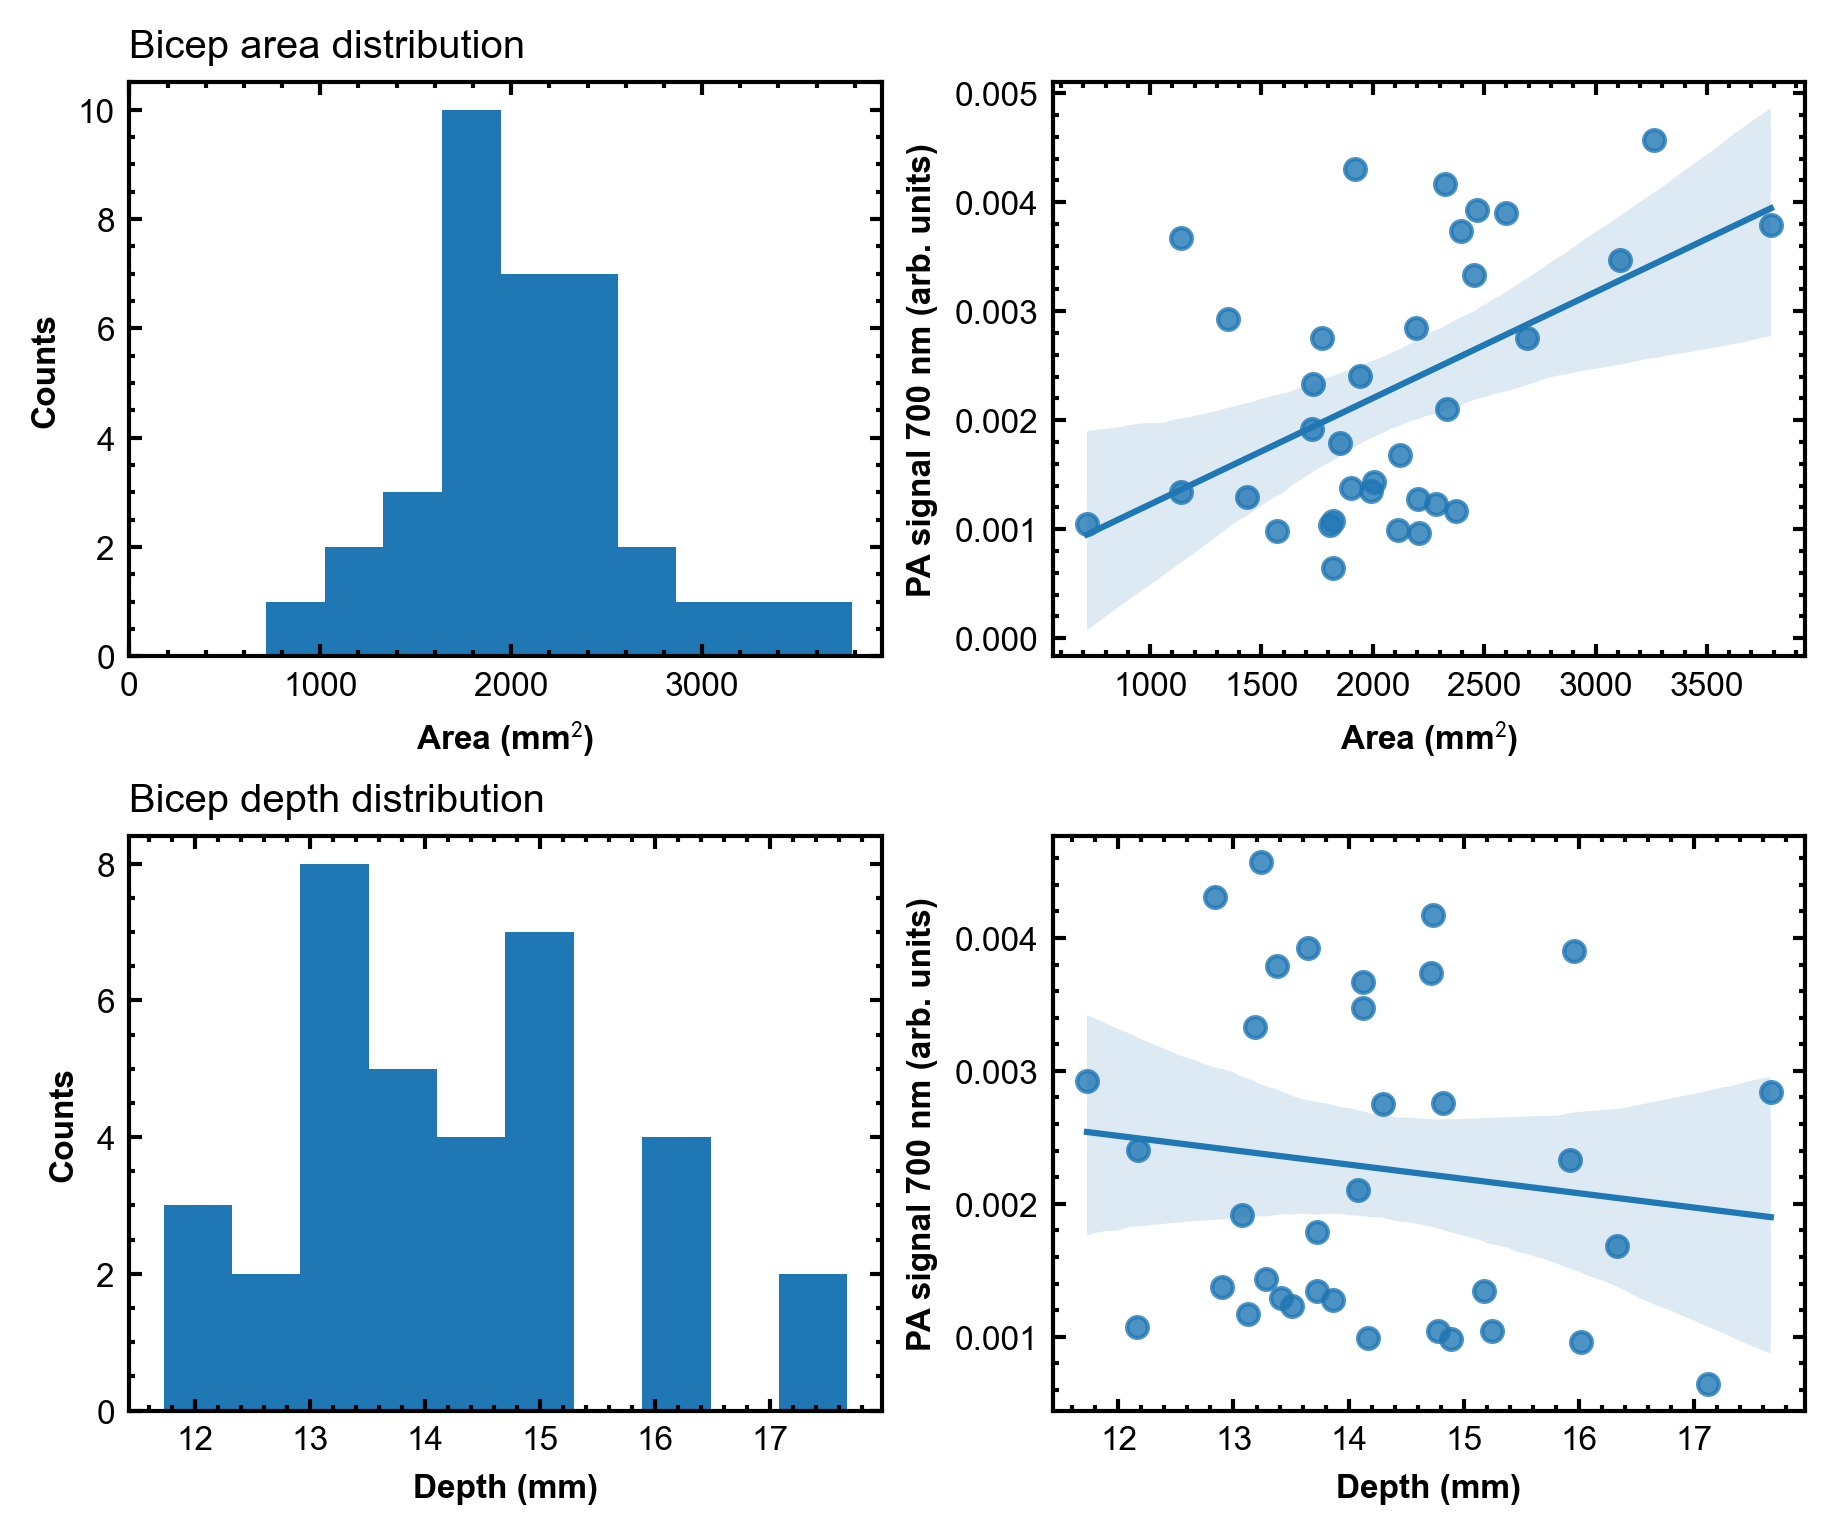

Mean = 2073.38 mm^2, Standard deviation = 599.58 mm^2, Percentage variation = 28.92 %
Depth: Mean = 14.20 mm, Standard deviation = 1.37 mm, Percentage variation = 9.67 %


In [9]:
region = "Bicep"
roi_name = "artery" if "artery" in region.lower() else "muscle"

fig, ((ax1, ax2), (ax4, ax3)) = plt.subplots(2, 2, figsize=(6, 5))

region_values = mean_values.query(
    f"`ROI Name` == '{roi_name}' and Region == '{region}'"
)

ax1.hist(
    region_values["ROI area"],
    bins=10,
)
ax1.set_xlabel("Area (mm$^2$)")
ax1.set_ylabel("Counts")
ax1.set_title(f"{region} area distribution", fontweight="normal", loc="left")
ax1.set_xlim([0, None])

# Plot the area against signal.
sns.regplot(data=region_values, x="ROI area", y="PA700", ax=ax2)

# ax2.scatter(region_values["ROI area"], region_values["PA700"])
ax2.set_xlabel("Area (mm$^2$)")
ax2.set_ylabel("PA signal 700 nm (arb. units)")

# Plot the area against signal.
sns.regplot(data=region_values, x="ROI y", y="PA700", ax=ax3)

# ax2.scatter(region_values["ROI area"], region_values["PA700"])
ax3.set_xlabel("Depth (mm)")
ax3.set_ylabel("PA signal 700 nm (arb. units)")

ax4.hist(
    region_values["ROI y"],
    bins=10,
)
ax4.set_xlabel("Depth (mm)")
ax4.set_ylabel("Counts")
ax4.set_title(f"{region} depth distribution", fontweight="normal", loc="left")
plt.show()
mean = region_values["ROI area"].mean()
std = region_values["ROI area"].std()
print(
    "Mean = {:.2f} mm^2, Standard deviation = {:.2f} mm^2, Percentage variation = {:.2f} %".format(
        mean, std, std / mean * 100
    )
)

mean = region_values["ROI y"].mean()
std = region_values["ROI y"].std()
print(
    "Depth: Mean = {:.2f} mm, Standard deviation = {:.2f} mm, Percentage variation = {:.2f} %".format(
        mean, std, std / np.abs(mean) * 100
    )
)

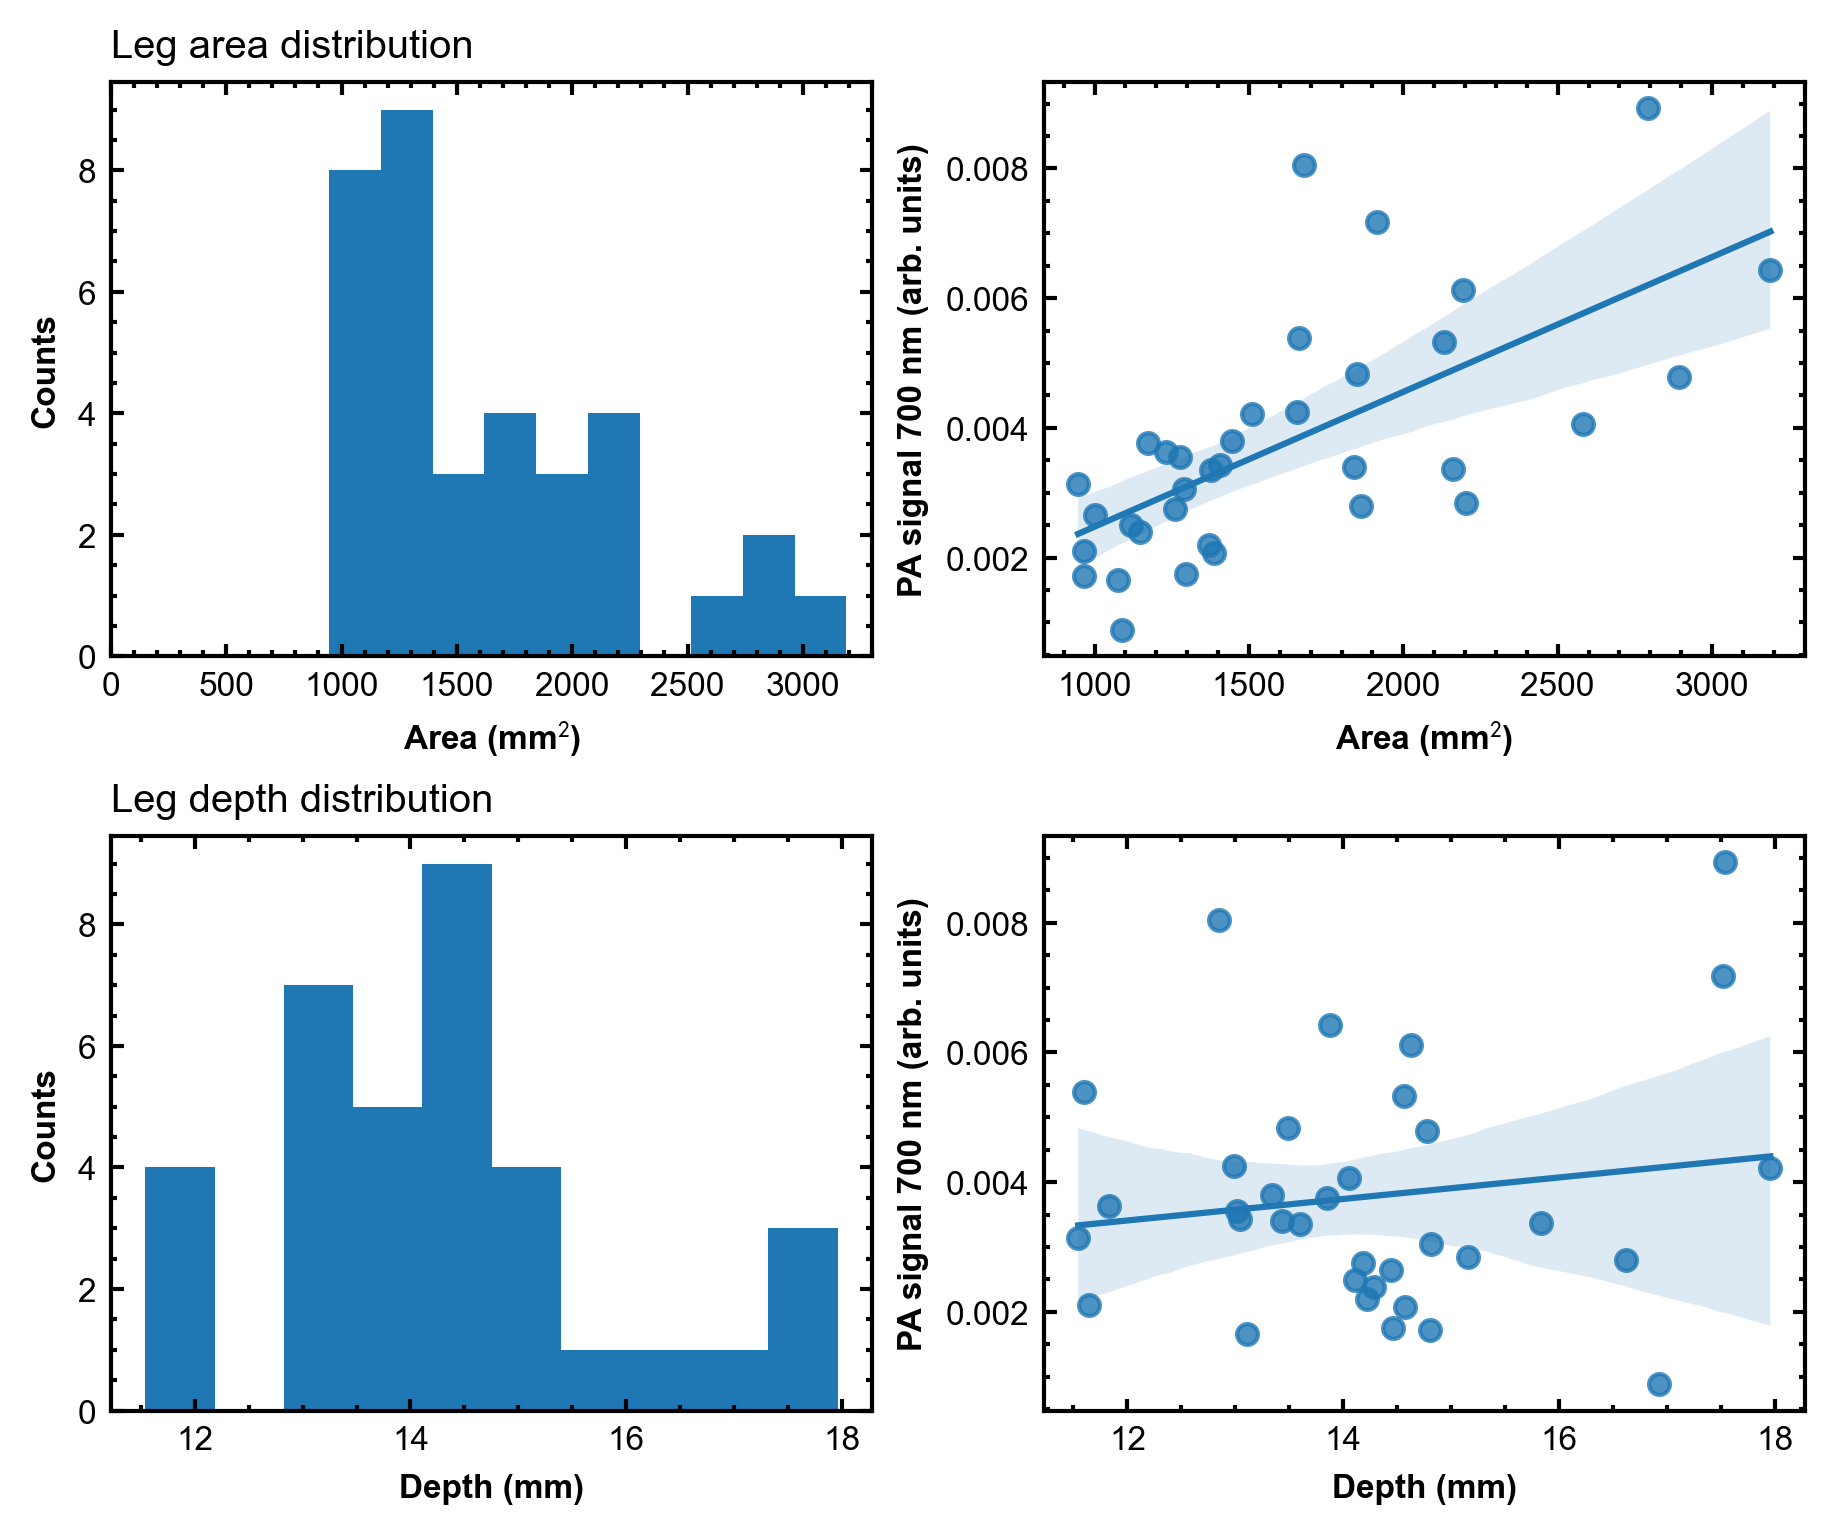

Mean = 1627.26 mm^2, Standard deviation = 585.90 mm^2, Percentage variation = 36.01 %
Depth: Mean = 14.25 mm, Standard deviation = 1.63 mm, Percentage variation = 11.45 %


In [10]:
region = "Leg"
roi_name = "artery" if "artery" in region.lower() else "muscle"

fig, ((ax1, ax2), (ax4, ax3)) = plt.subplots(2, 2, figsize=(6, 5))

region_values = mean_values.query(
    f"`ROI Name` == '{roi_name}' and Region == '{region}'"
)

ax1.hist(
    region_values["ROI area"],
    bins=10,
)
ax1.set_xlabel("Area (mm$^2$)")
ax1.set_ylabel("Counts")
ax1.set_title(f"{region} area distribution", fontweight="normal", loc="left")
ax1.set_xlim([0, None])

# Plot the area against signal.
sns.regplot(data=region_values, x="ROI area", y="PA700", ax=ax2)

# ax2.scatter(region_values["ROI area"], region_values["PA700"])
ax2.set_xlabel("Area (mm$^2$)")
ax2.set_ylabel("PA signal 700 nm (arb. units)")

# Plot the area against signal.
sns.regplot(data=region_values, x="ROI y", y="PA700", ax=ax3)

# ax2.scatter(region_values["ROI area"], region_values["PA700"])
ax3.set_xlabel("Depth (mm)")
ax3.set_ylabel("PA signal 700 nm (arb. units)")

ax4.hist(
    region_values["ROI y"],
    bins=10,
)
ax4.set_xlabel("Depth (mm)")
ax4.set_ylabel("Counts")
ax4.set_title(f"{region} depth distribution", fontweight="normal", loc="left")
plt.show()
mean = region_values["ROI area"].mean()
std = region_values["ROI area"].std()
print(
    "Mean = {:.2f} mm^2, Standard deviation = {:.2f} mm^2, Percentage variation = {:.2f} %".format(
        mean, std, std / mean * 100
    )
)

mean = region_values["ROI y"].mean()
std = region_values["ROI y"].std()
print(
    "Depth: Mean = {:.2f} mm, Standard deviation = {:.2f} mm, Percentage variation = {:.2f} %".format(
        mean, std, std / np.abs(mean) * 100
    )
)

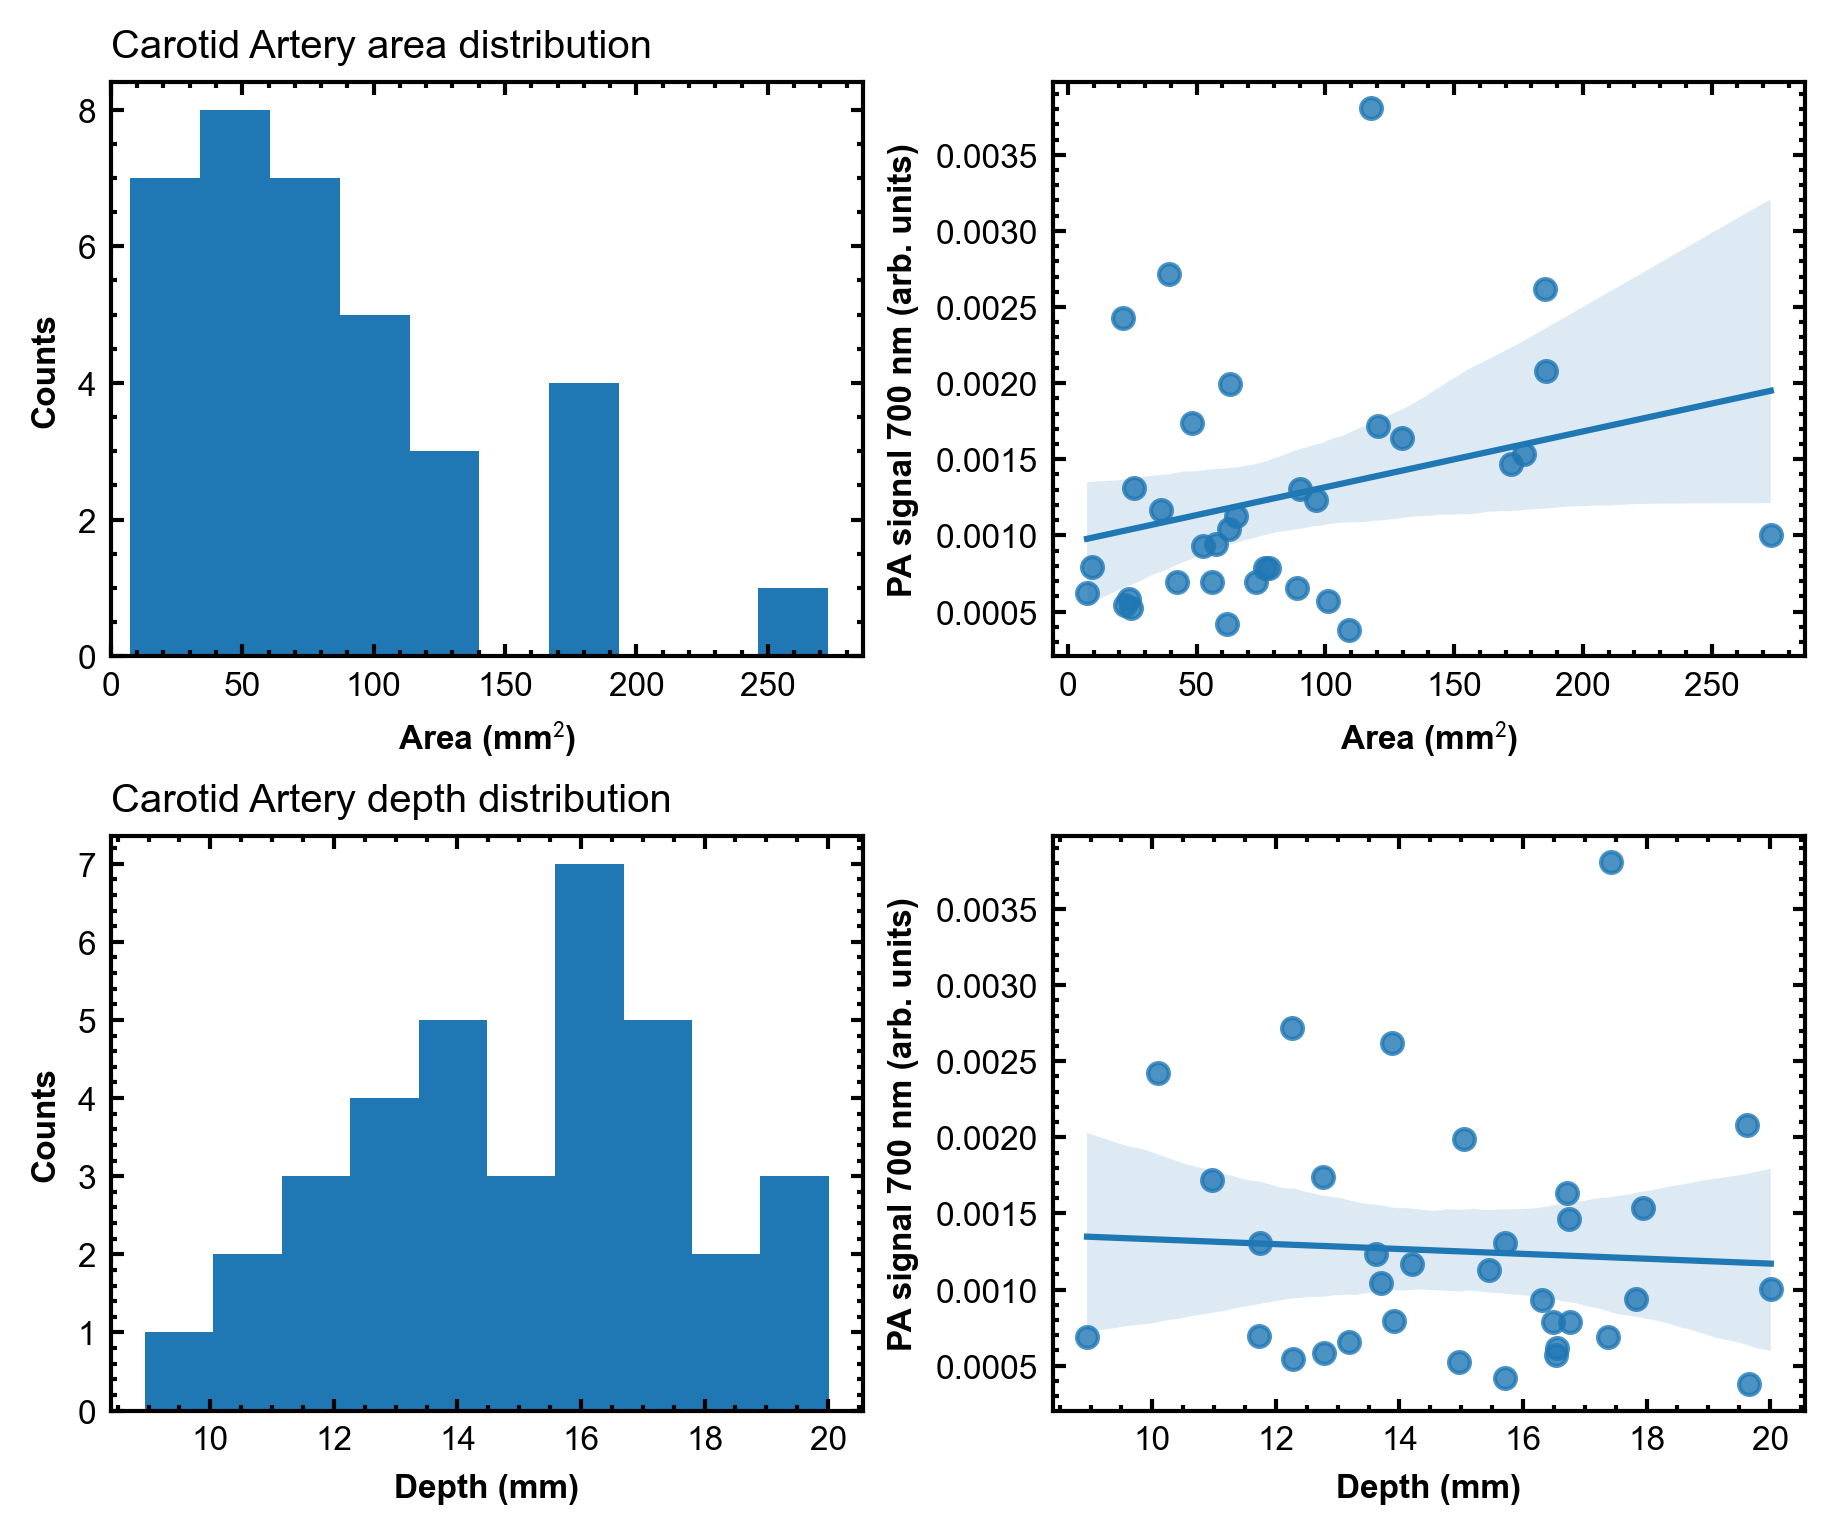

Area: Mean = 81.01 mm^2, Standard deviation = 59.74 mm^2, Percentage variation = 73.74 %
Diameter = 9.51 mm, Standard deviation = 3.61 mm, Percentage variation = 37.93 %
Depth: Mean = 15.00 mm, Standard deviation = 2.71 mm, Percentage variation = 18.07 %


In [11]:
region = "Carotid Artery"
roi_name = "artery" if "artery" in region.lower() else "muscle"

fig, ((ax1, ax2), (ax4, ax3)) = plt.subplots(2, 2, figsize=(6, 5))

region_values = mean_values.query(
    f"`ROI Name` == '{roi_name}' and Region == '{region}'"
)

ax1.hist(
    region_values["ROI area"],
    bins=10,
)
ax1.set_xlabel("Area (mm$^2$)")
ax1.set_ylabel("Counts")
ax1.set_title(f"{region} area distribution", fontweight="normal", loc="left")
ax1.set_xlim([0, None])

# Plot the area against signal.
sns.regplot(data=region_values, x="ROI area", y="PA700", ax=ax2)

# ax2.scatter(region_values["ROI area"], region_values["PA700"])
ax2.set_xlabel("Area (mm$^2$)")
ax2.set_ylabel("PA signal 700 nm (arb. units)")

# Plot the area against signal.
sns.regplot(data=region_values, x="ROI y", y="PA700", ax=ax3)

# ax2.scatter(region_values["ROI area"], region_values["PA700"])
ax3.set_xlabel("Depth (mm)")
ax3.set_ylabel("PA signal 700 nm (arb. units)")

ax4.hist(
    region_values["ROI y"],
    bins=10,
)
ax4.set_xlabel("Depth (mm)")
ax4.set_ylabel("Counts")
ax4.set_title(f"{region} depth distribution", fontweight="normal", loc="left")
plt.show()


mean = region_values["ROI area"].mean()
std = region_values["ROI area"].std()
print(
    "Area: Mean = {:.2f} mm^2, Standard deviation = {:.2f} mm^2, Percentage variation = {:.2f} %".format(
        mean, std, std / mean * 100
    )
)

diameter = np.sqrt(4 * region_values["ROI area"] / np.pi)
mean = diameter.mean()
std = diameter.std()
print(
    "Diameter = {:.2f} mm, Standard deviation = {:.2f} mm, Percentage variation = {:.2f} %".format(
        mean, std, std / mean * 100
    )
)

mean = region_values["ROI y"].mean()
std = region_values["ROI y"].std()
print(
    "Depth: Mean = {:.2f} mm, Standard deviation = {:.2f} mm, Percentage variation = {:.2f} %".format(
        mean, std, std / np.abs(mean) * 100
    )
)

In [12]:
comparator = "ITA"  # OR ITA OR Age

0.9638374632611832
0.14459453057766455


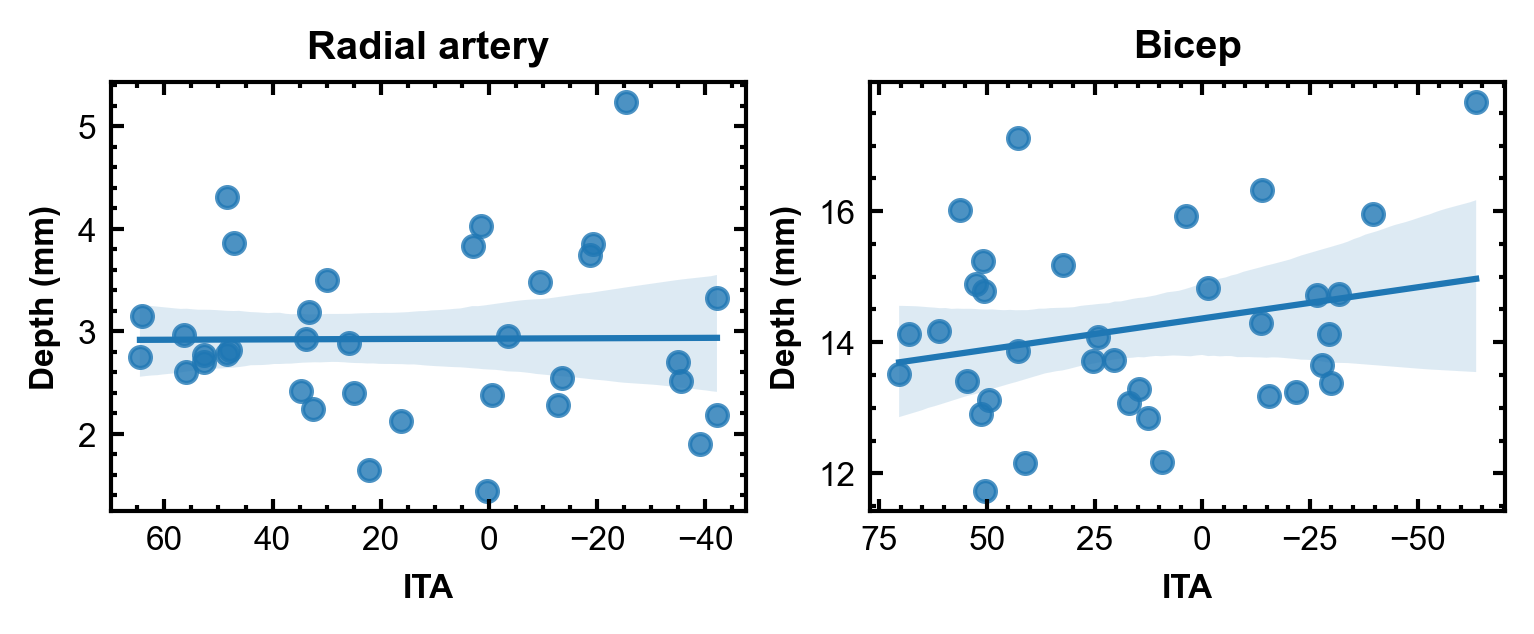

In [13]:
region = "Radial Artery"
roi_name = "artery" if "artery" in region.lower() else "muscle"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5, 2))

region_values = mean_values.query(
    f"`ROI Name` == '{roi_name}' and Region == '{region}'"
)

# Plot the area against signal.

print(linregress(region_values[comparator], region_values["ROI y"]).pvalue)
sns.regplot(
    data=region_values,
    y="ROI y",
    x=comparator,
    ax=ax1,
)

region = "Bicep"
roi_name = "artery" if "artery" in region.lower() else "muscle"

region_values = mean_values.query(
    f"`ROI Name` == '{roi_name}' and Region == '{region}'"
)

# Plot the area against signal.

sns.regplot(
    data=region_values,
    y="ROI y",
    x=comparator,
    ax=ax2,
)

print(linregress(region_values[comparator], region_values["ROI y"]).pvalue)

ax1.set_title("Radial artery")
ax2.set_title("Bicep")
ax1.set_ylabel("Depth (mm)")
ax2.set_ylabel("Depth (mm)")

if comparator == "ITA":
    ax1.invert_xaxis()
    ax2.invert_xaxis()
plt.show()